<a href="https://colab.research.google.com/github/thanhduc17/ML/blob/main/Gradient_Descent_cho_b%C3%A0i_to%C3%A1n_h%E1%BB%93i_quy_tuy%E1%BA%BFn_t%C3%ADnh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Hàm hồi quy tuyến tính

Với dữ liệu:

x1: size  
x2: bedroom  
y: price  

Mô hình:
$$
y = w_0 + w_1 x_1 + w_2 x_2
$$






## 2. Hàm MSE (Mean Squared Error)

$$
J(w_0, w_1, w_2) = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2
$$

Trong đó:

- $n$: số mẫu  
- $\hat{y}_i = w_0 + w_1 x_{1i} + w_2 x_{2i}$

## 3. Tính Gradient

Ta đạo hàm hàm mất mát theo từng tham số:

$$
\frac{\partial J}{\partial w_0} = \frac{2}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)
$$

$$
\frac{\partial J}{\partial w_1} = \frac{2}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i) x_{1i}
$$

$$
\frac{\partial J}{\partial w_2} = \frac{2}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i) x_{2i}
$$

LR=0.001: w0=238005.7457, w1=67353.4234, w2=19738.8683
LR=0.01: w0=340410.8075, w1=109159.3062, w2=-6289.8652
LR=0.1: w0=340412.6596, w1=109447.7965, w2=-6578.3549


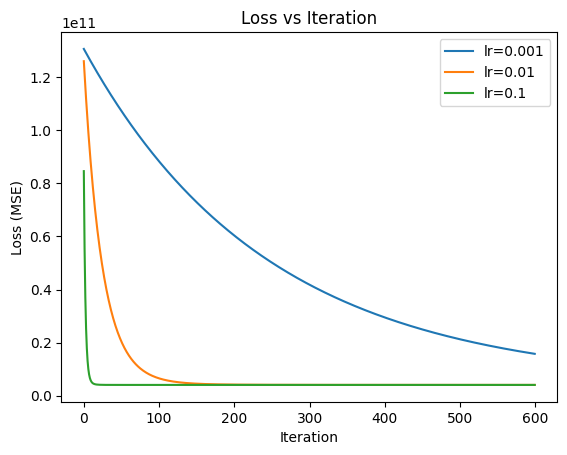

In [ ]:
import csv
import random
import matplotlib.pyplot as plt

# Đọc dữ liệu
X1, X2, Y = [], [], []

with open('data.csv', 'r') as f:
    reader = csv.reader(f)
    next(reader)  # bỏ header
    for row in reader:
        X1.append(float(row[0]))  # size
        X2.append(float(row[1]))  # bedroom
        Y.append(float(row[2]))   # price

n = len(Y)

# Chuẩn hóa (QUAN TRỌNG để GD hội tụ tốt)
def normalize(arr):
    mean = sum(arr)/len(arr)
    std = (sum((x-mean)**2 for x in arr)/len(arr))**0.5
    return [(x-mean)/std for x in arr]

X1 = normalize(X1)
X2 = normalize(X2)

# Hàm dự đoán
def predict(w0, w1, w2, x1, x2):
    return w0 + w1*x1 + w2*x2

# Hàm loss
def compute_loss(w0, w1, w2):
    total = 0
    for i in range(n):
        y_hat = predict(w0, w1, w2, X1[i], X2[i])
        total += (y_hat - Y[i])**2
    return total / n

# Gradient Descent
def gradient_descent(lr, epochs):
    w0 = random.random()
    w1 = random.random()
    w2 = random.random()

    losses = []

    for epoch in range(epochs):
        dw0 = dw1 = dw2 = 0

        for i in range(n):
            y_hat = predict(w0, w1, w2, X1[i], X2[i])
            error = y_hat - Y[i]

            dw0 += error
            dw1 += error * X1[i]
            dw2 += error * X2[i]

        dw0 = (2/n) * dw0
        dw1 = (2/n) * dw1
        dw2 = (2/n) * dw2

        # cập nhật
        w0 -= lr * dw0
        w1 -= lr * dw1
        w2 -= lr * dw2

        loss = compute_loss(w0, w1, w2)
        losses.append(loss)

    return w0, w1, w2, losses

# Chạy với 3 learning rate
lrs = [0.001, 0.01, 0.1]
results = {}

for lr in lrs:
    w0, w1, w2, losses = gradient_descent(lr, 600)
    results[lr] = losses
    print(f"LR={lr}: w0={w0:.4f}, w1={w1:.4f}, w2={w2:.4f}")

# Vẽ loss
for lr in lrs:
    plt.plot(results[lr], label=f"lr={lr}")

plt.xlabel("Iteration")
plt.ylabel("Loss (MSE)")
plt.title("Loss vs Iteration")
plt.legend()
plt.show()